<a href="https://colab.research.google.com/github/donatelk/kgdneuro265/blob/main/homework/practice_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###Kelsey Donatelli

Practice homework

In [1]:
#Import packages
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Import data
acc_hits_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_hits_hw6.csv'
acc_fa_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_fa_hw6.csv'
lc_hits_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_hits_hw6.csv'
lc_fa_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_fa_hw6.csv'

acc_hits= np.loadtxt(acc_hits_url, delimiter=',')
acc_fa= np.loadtxt(acc_fa_url, delimiter=',')
lc_hits= np.loadtxt(lc_hits_url, delimiter=',')
lc_fa= np.loadtxt(lc_fa_url, delimiter=',')

In [5]:
#Shape of each array
print(acc_hits.shape)
print(acc_fa.shape)
print(lc_hits.shape)
print(lc_fa.shape)

(14, 8001)
(19, 8001)
(14, 8001)
(19, 8001)


In [6]:
#Creat time variable
time= np.linspace(0,4,8001)

In [7]:
#Sampling rate
sampling_rate= 8001/4
sampling_rate

2000.25

Text(0.5, 1.0, 'Acc and Lc FA Trial 1')

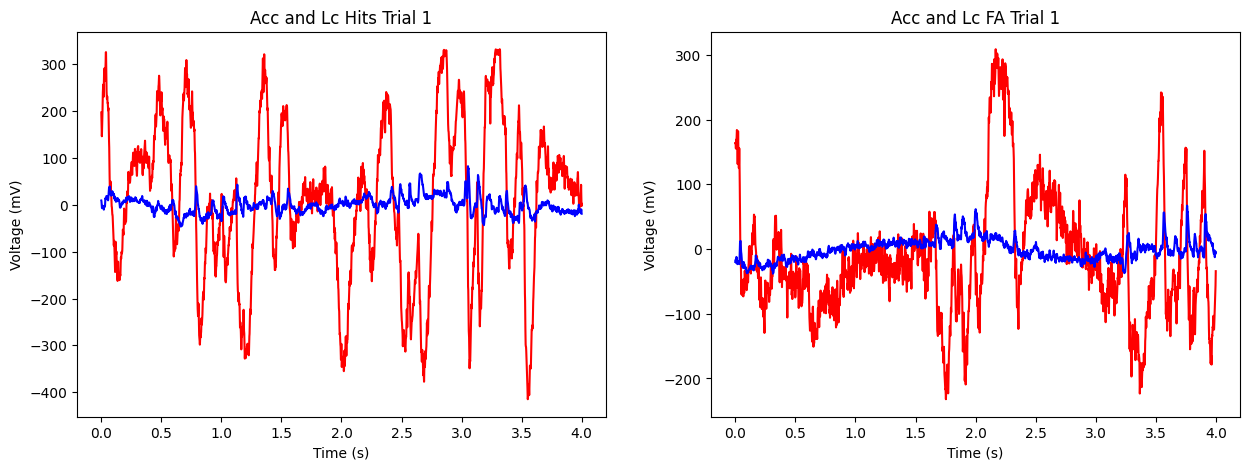

In [8]:
#First trials for Acc and Lc hits and fa
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(time, acc_hits[0], color= 'red')
ax[0].plot(time, lc_hits[0], color= 'blue')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Voltage (mV)')
ax[0].set_title('Acc and Lc Hits Trial 1')

ax[1].plot(time, acc_fa[0], color= 'red')
ax[1].plot(time, lc_fa[0], color= 'blue')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Voltage (mV)')
ax[1].set_title('Acc and Lc FA Trial 1')

The acc hits looks like it has a lower dominant ossilation around 2-3. The acc fa also has a lower dominant ossilation but is more variable, perhaps closer to 1. The dominant ossilation for lc hits and fa seems to be much higher.

The hit and fa are similar in that the red has a lower ossilation while the blue is higher. However, the fa is more irregular. I do not see consistent relationships across time.

Text(0.5, 1.0, 'Coherence between two electrodes')

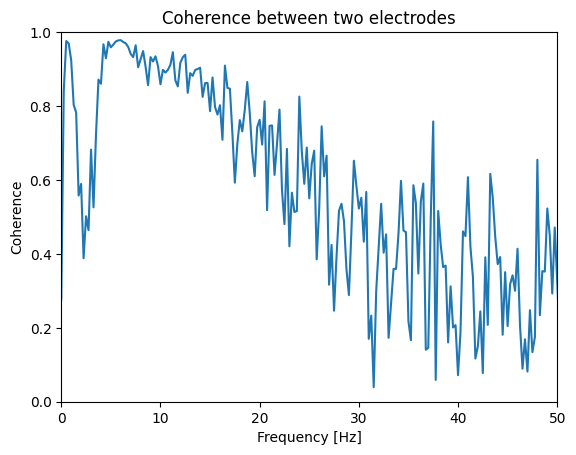

In [11]:
#Coherence for Acc and Lc Hits

# Compute the Fourier transforms
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_hits])
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_hits])

# Time variables
T = time[-1]
dt = time[1] - time[0]

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)
Syy = scale * (yf * yf.conj()).mean(0)
Sxy = scale * (xf * yf.conj()).mean(0)

# Compute the coherence.
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f = np.fft.rfftfreq(N, dt)                     # Define a frequency axis.
plt.plot(f, cohr.real)                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')


There seems to be the most phase coherence around the 5-10Hz frequency band.

Text(0.5, 1.0, 'Coherence between two electrodes')

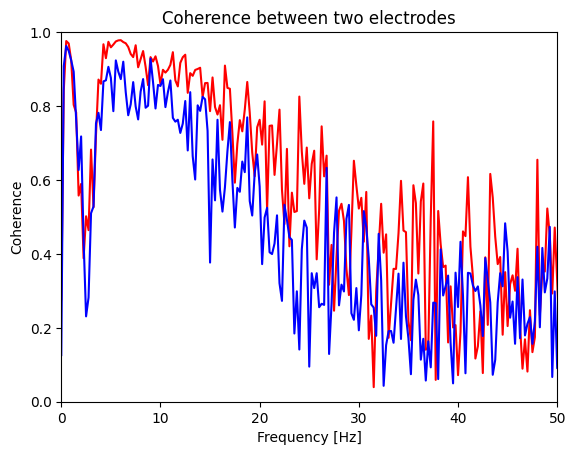

In [13]:
#Coherence for Acc and Lc Hits and Fas

#Coherence for Acc and Lc Hits

# Compute the Fourier transforms
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_hits])
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_hits])
xf_fa = np.array([np.fft.rfft(x - x.mean()) for x in acc_fa])
yf_fa = np.array([np.fft.rfft(y - y.mean()) for y in lc_fa])

# Time variables
T = time[-1]
dt = time[1] - time[0]

# Compute the spectra for hits
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)
Syy = scale * (yf * yf.conj()).mean(0)
Sxy = scale * (xf * yf.conj()).mean(0)

# Compute the coherence for hits
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))


# Compute the spectra for fas
T = time[-1]
scale_fa = 2 * dt**2 / T
Sxx_fa = scale_fa * (xf_fa * xf_fa.conj()).mean(0)
Syy_fa = scale_fa * (yf_fa * yf_fa.conj()).mean(0)
Sxy_fa = scale_fa * (xf_fa * yf_fa.conj()).mean(0)

# Compute the coherence for fas
cohr_fa = np.abs(Sxy_fa) / (np.sqrt(Sxx_fa) * np.sqrt(Syy_fa))


#Axis labels and limits
f = np.fft.rfftfreq(N, dt)
plt.plot(f, cohr.real, color= 'red')
plt.plot(f, cohr_fa.real, color='blue')
plt.xlim([0, 50])
plt.ylim([0, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')


This shows that there is a similar coherence fequency between the hits and the fas, with coherence being slightly lower for fa. This means the brain areas are talking to each other more buring hits.